<a href="https://colab.research.google.com/github/sabuj10h/Machine-learning-practice-/blob/main/all_model_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df=pd.read_csv('/content/used_car_price_prediction_practice.csv')
df.head()

,Car_ID,Brand,Model,Year,Mileage_km,Fuel_Type,Transmission,Engine_CC,Owner_Count,Accident_History,Service_History,Location,Seller_Type,Price_Lakh
0,10001,Ford,Mustang,2013,58151.0,Petrol,Automatic,2000.0,2,No,Partial,Rajshahi,Individual,8.11
1,10002,BMW,3 Series,2019,116755.0,Petrol,Automatic,3000.0,4,No,Full,Khulna,Dealer,30.89
2,10003,Mercedes,GLC,2009,51176.0,Petrol,Automatic,1300.0,1,No,Partial,Sylhet,Dealer,34.17
3,10004,Ford,Focus,2014,85137.0,Hybrid,Manual,1600.0,2,Yes,Partial,Chattogram,Individual,4.00
4,10005,Nissan,Sunny,2023,90448.0,Hybrid,Manual,1300.0,3,No,Partial,Dhaka,Dealer,11.60


In [ ]:
print("\nData Info:")
print(df.info())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1808 entries, 0 to 1807
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Car_ID            1808 non-null   int64  
 1   Brand             1808 non-null   object 
 2   Model             1808 non-null   object 
 3   Year              1808 non-null   int64  
 4   Mileage_km        1801 non-null   float64
 5   Fuel_Type         1808 non-null   object 
 6   Transmission      1808 non-null   object 
 7   Engine_CC         1798 non-null   float64
 8   Owner_Count       1808 non-null   int64  
 9   Accident_History  1808 non-null   object 
 10  Service_History   1629 non-null   object 
 11  Location          1808 non-null   object 
 12  Seller_Type       1808 non-null   object 
 13  Price_Lakh        1808 non-null   float64
dtypes: float64(3), int64(3), object(8)
memory usage: 197.9+ KB
None

Data Types:
Car_ID                int64
Brand              

In [ ]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Numerical columns:", len(df.select_dtypes(include="number").columns))
print("Categorical columns:", len(df.select_dtypes(include="object").columns))
print("Target:","Price_Lakh")

Shape: (1808, 14)
Missing values: 196
Duplicates: 8
Numerical columns: 6
Categorical columns: 8
Target: Price_Lakh


In [ ]:
df=df.drop_duplicates()
df.shape

(1800, 14)

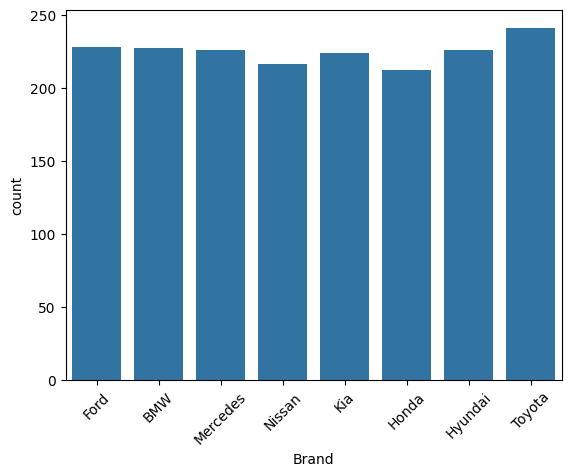

In [ ]:
sns.countplot(data=df, x="Brand")
plt.xticks(rotation=45)
plt.show()

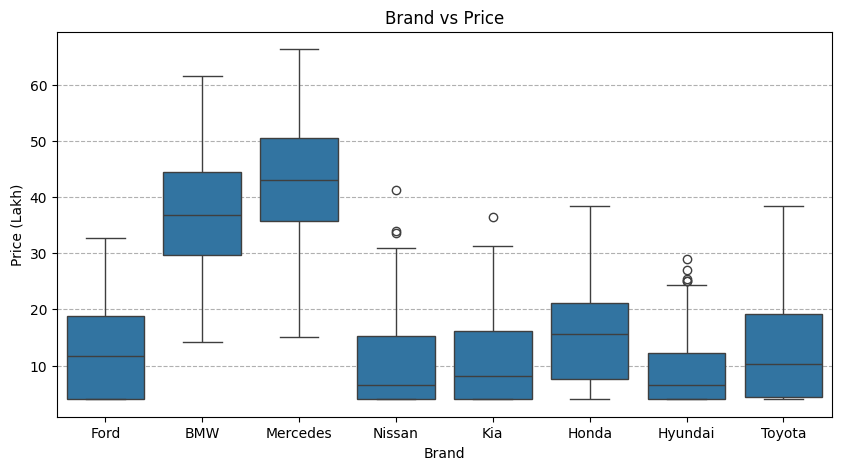

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Brand", y="Price_Lakh")

plt.grid(axis="y", linestyle="--", alpha=1)

plt.title("Brand vs Price")
plt.xlabel("Brand")
plt.ylabel("Price (Lakh)")

plt.show()

In [ ]:
X= df.drop(columns=["Price_Lakh","Car_ID"])
y = df["Price_Lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1440, 12)
X_test shape: (360, 12)
y_train shape: (1440,)
y_test shape: (360,)


In [ ]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Year', 'Mileage_km', 'Engine_CC', 'Owner_Count']
Categorical features: ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Accident_History', 'Service_History', 'Location', 'Seller_Type']


In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
Linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])


Linear_model.fit(X_train, y_train)

y_Linear = Linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_Linear)
mse = mean_squared_error(y_test, y_Linear)
rmse = mean_squared_error(y_test, y_Linear) ** 0.5
r2 = r2_score(y_test, y_Linear)


print("\nModel Evaluation")
print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))




Model Evaluation
MAE: 3.03
MSE: 14.41
RMSE: 3.8
R² Score: 0.942


In [ ]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=5,
        random_state=0
    ))
])


# 11. Train model
dt_model.fit(X_train, y_train)


# 12. Prediction
y_pred_dt = dt_model.predict(X_test)


# 13. Evaluation
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = mean_squared_error(y_test, y_pred_dt) ** 0.5
r2 = r2_score(y_test, y_pred_dt)


print("\nModel Evaluation")
print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))


Model Evaluation
MAE: 4.95
MSE: 43.75
RMSE: 6.61
R² Score: 0.825


In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=0
    ))
])


# 11. Train model
rf_model.fit(X_train, y_train)


# 12. Prediction
y_pred_rf = rf_model.predict(X_test)


# 13. Evaluation
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2 = r2_score(y_test, y_pred_rf)


print("\nModel Evaluation")
print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))


Model Evaluation
MAE: 3.51
MSE: 22.02
RMSE: 4.69
R² Score: 0.912


ALL model Result

In [ ]:
models = {
    "Linear Regression": Linear_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R² Score"]
)

results_df

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,3.032618,14.407011,3.795657,0.942407
1,Decision Tree,4.953567,43.745552,6.614042,0.825124
2,Random Forest,3.514899,22.023064,4.692874,0.911961


In [ ]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("\n================ CROSS VALIDATION ================")

print("CV Scores:")
print(np.round(cv_scores, 3))

print(
    "Mean CV r2_score:",
    round(cv_scores.mean(), 3))


================ CROSS VALIDATION ================
CV Scores:
[0.891 0.901 0.883 0.892 0.884]
Mean CV r2_score: 0.89


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    dt_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best CV Score: 0.8307525208345332


In [ ]:
final_model = Linear_model
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred_final)
final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_final)

print("\n================ FINAL MODEL ================")

print("Final Model: Linear Regression")
print("MAE:", round(final_mae, 2))
print("MSE:", round(final_mse, 2))
print("RMSE:", round(final_rmse, 2))
print("R² Score:", round(final_r2, 3))


================ FINAL MODEL ================
Final Model: Linear Regression
MAE: 3.03
MSE: 14.41
RMSE: 3.8
R² Score: 0.942
